#### Objetivo: Código de teste para aplicar varmax adicionando manualmente o número de lagas para teste, grau de polinômios (exógenas e endógena) e também tenta adicionar as influências das partes reais e imaginárias

In [1]:
# ---------------------
# Incluindo Bibliotecas
# ---------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VARMAX
from statsmodels.iolib.smpickle import load_pickle
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from itertools import product,combinations
from pathlib import Path

In [2]:
# ---------------------------------------
# Função de Criação Automática de Lag (m)
# ---------------------------------------
def select_auto_lag(df_exog,exog_cols,max_x_lag=2,inplace=True) -> pd.DataFrame:
  """
  Aplica os lags desejado às exógenas da base de dados original e retorna o dataframe com as novas colunas
  """
  new_exog_cols = list(exog_cols)

  for lag in range(1, max_x_lag + 1):
    for col in exog_cols:
      lag_cols_name = f'{col}_lag{lag}'
      df_exog[lag_cols_name] = df_exog[col].shift(lag)
      new_exog_cols.append(lag_cols_name)

  lag_cols = [f'{col}_lag{lag}' for lag in range(1, max_x_lag+1) for col in exog_cols]
  rows_to_drop = df_exog.index[df_exog[lag_cols].isna().any(axis=1)]

  df_exog = df_exog.drop(index=rows_to_drop)
  return df_exog,new_exog_cols

In [3]:
# -------------------------------------------------
# Função de Seleção de grau de Polinômio de Lag (m)
# -------------------------------------------------
def select_auto_polinomial_degree(df_exog,exog_cols,degree_type,max_degree=1) -> pd.DataFrame:
  """
  Aplica os graus desejado às exógenas da base de dados original, gerando o polinômio completo para cada coluna
  das exógenas (originais e sem lags) e retorna o dataframe com as novas colunas
  """
  new_exog_cols = list(exog_cols)
  new_columns = {}

  if degree_type in ['real','r','REAL','Real']:
    degree_type = 'real'
  elif degree_type in ['img','i','IMG','Img']:
    degree_type = 'img'
  else:
    raise ValueError("degree_type must be 'real' or 'img'")

  # Aplicando graus para série de dados reais
  if max_degree >= 2:
    for degree in range(2, max_degree + 1):
      columns = [col for col in exog_cols if degree_type in col]
      for col in columns:
        degree_col_name = f'{col}_deg{degree}'
        new_columns[degree_col_name] = df_exog[col] ** degree
        new_exog_cols.append(degree_col_name)

  if new_columns:
    df_exog = pd.concat([df_exog,pd.DataFrame(new_columns,index=df_exog.index)],axis=1)

  return df_exog,new_exog_cols

In [4]:
# -----------------------------------------
# Função de Forecast e Cálculo das Métricas
# -----------------------------------------
def get_forecast_metrics(p, res, val, endog_cols, current_exog_cols) -> dict:
    """
    Calcula as métricas de avaliação da previsão realizada pelo modelo
    """
    fc = res.forecast(steps=len(val[list(endog_cols)]), exog=val[current_exog_cols])
    metrics = {}

    for col in endog_cols:
        y_true = val[col]
        y_pred = fc[col]

        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - p - 1)
        std_err = np.std(y_true - y_pred)

        metrics[col] = {
          'MSE':    mse,
          'RMSE':   rmse,
          'MAE':    mae,
          'R2':     r2,
          'AdjR2':  adj_r2,
          'STD':    std_err,
        }

    # Métricas globais do modelo
    metrics['rmse_mean'] = np.mean([metrics[col]['RMSE'] for col in endog_cols])
    metrics['aic'] = getattr(res, 'aic', np.nan)
    metrics['bic'] = getattr(res, 'bic', np.nan)

    return metrics

In [5]:
# -----------------------------
# Função de Impressão dos Dados
# -----------------------------
def view_result(data, meta=None, endog_cols=('Yreal', 'Yimg')):
    """
    Imprime na tela as métricas calculadas de acordo com a previsão do modelo.
    Aceita `data` como dicionário ou DataFrame (métricas nas linhas, colunas endog nas colunas).
    `meta` é obrigatório quando `data` for um DataFrame: dict com p, aic, bic, rmse_mean, x_lag, exog_degree.
    """
    metric_labels = [
        ('RMSE',  'RMSE'),
        ('MAE',   'MAE'),
        ('R2',    'R²'),
        ('AdjR2', 'R² Ajust'),
        ('STD',   'STD')]

    W_METRIC = 10
    W_VAL    = 10

    def sep(l, m, r, n_cols):
        block = '─' * (W_METRIC + W_VAL + 3)
        return l + m.join([block] * n_cols) + r

    def row_str(pairs):
        cells = [f' {lbl:<{W_METRIC}} {val:>{W_VAL}} ' for lbl, val in pairs]
        return '│' + '│'.join(cells) + '│'

    is_df = isinstance(data, pd.DataFrame)

    def get_meta(key):
        return meta[key] if is_df else data[key]

    def get_metric(col, key):
        return data.at[key, col] if is_df else data[col][key]

    print(f'Lag={get_meta("p")}')
    print(f'  AIC={get_meta("aic"):.2f} | BIC={get_meta("bic"):.2f} | RMSE Mean={get_meta("rmse_mean"):.4f}')
    print(f'  X Lag={get_meta("x_lag")} | Exog Degree={get_meta("exog_degree")}')

    print(sep('  ┌', '┬', '┐', len(endog_cols)))
    print('  ' + row_str([(col, '') for col in endog_cols]))
    print(sep('  ├', '┼', '┤', len(endog_cols)))

    for key, lbl in metric_labels:
        pairs = []
        for col in endog_cols:
            val    = get_metric(col, key)
            v_str  = f'{val:+.4f}' if key in ('R2', 'AdjR2') else f'{val:.4f}'
            pairs.append((lbl, v_str))
        print('  ' + row_str(pairs))

    print(sep('  └', '┴', '┘', len(endog_cols)))

In [6]:
# ------------------------------------------------
# Função de Recuperação de Dados para Visualização
# ------------------------------------------------
def row_to_metrics_df(row: pd.Series, endog_cols: list) -> tuple[pd.DataFrame, dict]:
    """
    Reconstrói o df_metrics e meta a partir de uma linha do DataFrame de resultados.
    """
    metric_keys = ['MSE', 'RMSE', 'MAE', 'R2', 'AdjR2', 'STD']
    meta_keys   = ['p', 'x_lag', 'exog_degree', 'trend', 'aic', 'bic', 'rmse_mean']

    records = {}
    for col in endog_cols:
        records[col] = {m: row[f'{col}_{m}'] for m in metric_keys}

    df_metrics = pd.DataFrame(records)
    meta       = {k: row[k] for k in meta_keys}

    return df_metrics, meta

#### Leitura dos dataframes iniciais

In [7]:
project_path = Path.cwd().parent
data = pd.read_excel("../data/dadosIniciais.xlsx")

In [8]:
df_input = pd.DataFrame()
df_input["Xreal"] = data.iloc[:,0]
df_input["Ximg"] = data.iloc[:,1]

In [9]:
df_output = pd.DataFrame()
df_output["Yreal"] = data.iloc[:,2]
df_output["Yimg"] = data.iloc[:,3]

In [10]:
df_concat = pd.concat([df_output,df_input],axis=1)

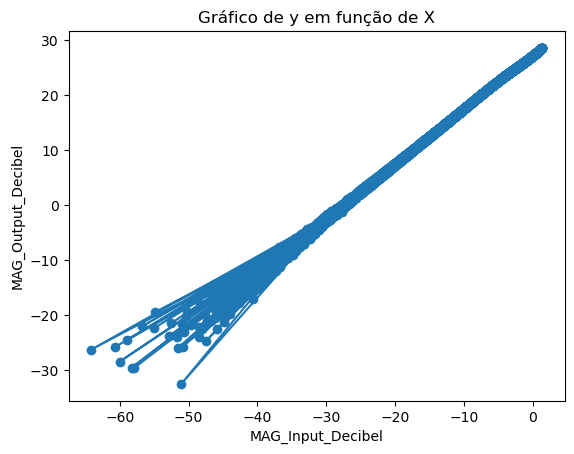

In [11]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output"] = np.sqrt(df_concat["Yreal"]**2 + df_concat["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel"]= 20 * np.log10(df_mag["MAG_Output"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel"]= df_mag["MAG_Output_Decibel"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel')
plt.title('Gráfico de y em função de X')
plt.show()

#### Teste de geração de lags

In [12]:
current_exog_cols = ["Xreal","Ximg"]
cp_df_input = df_input.copy()
cp_df_input, current_exog_cols = select_auto_lag(cp_df_input,current_exog_cols,max_x_lag=5,inplace=False)

print(f"current_exog_cols: {current_exog_cols}")

current_exog_cols: ['Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_lag3', 'Ximg_lag3', 'Xreal_lag4', 'Ximg_lag4', 'Xreal_lag5', 'Ximg_lag5']


#### Teste de Geração de Graus de Polinômio

In [13]:
exog_cols = cp_df_input.columns
current_exog_cols = list(exog_cols)
cp_df_input, current_exog_cols = select_auto_polinomial_degree(cp_df_input,exog_cols,'r',max_degree=3)

print(f"{[col for col in list(cp_df_input.columns) if 'X' in col]}")
print(f"current_exog_cols: {current_exog_cols}")

['Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_lag3', 'Ximg_lag3', 'Xreal_lag4', 'Ximg_lag4', 'Xreal_lag5', 'Ximg_lag5', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_lag3_deg2', 'Xreal_lag4_deg2', 'Xreal_lag5_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Xreal_lag3_deg3', 'Xreal_lag4_deg3', 'Xreal_lag5_deg3']
current_exog_cols: ['Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_lag3', 'Ximg_lag3', 'Xreal_lag4', 'Ximg_lag4', 'Xreal_lag5', 'Ximg_lag5', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_lag3_deg2', 'Xreal_lag4_deg2', 'Xreal_lag5_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Xreal_lag3_deg3', 'Xreal_lag4_deg3', 'Xreal_lag5_deg3']


In [14]:
real_exog_cols = [col for col in current_exog_cols if 'real' in col]
img_exog_cols = [col for col in current_exog_cols if 'img' in col]

print(f"real_exog_cols: {real_exog_cols}")
print(f"img_exog_cols: {img_exog_cols}")

real_exog_cols: ['Xreal', 'Xreal_lag1', 'Xreal_lag2', 'Xreal_lag3', 'Xreal_lag4', 'Xreal_lag5', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_lag3_deg2', 'Xreal_lag4_deg2', 'Xreal_lag5_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Xreal_lag3_deg3', 'Xreal_lag4_deg3', 'Xreal_lag5_deg3']
img_exog_cols: ['Ximg', 'Ximg_lag1', 'Ximg_lag2', 'Ximg_lag3', 'Ximg_lag4', 'Ximg_lag5']


#### Teste de Treinamento do Modelo e Visualização dos Dados

In [15]:
# --------------------------------------------
# Função de Seleção de Teste de Lag (m)
# --------------------------------------------
def calc_train_sect(data: pd.DataFrame, train_frac: float, val_frac: float):
    n = len(data)
    train_end = int(n * train_frac)
    val_end   = int(n * (train_frac + val_frac))
    return train_end, val_end

In [16]:
# --------------------------------------------
# Geração do DataFrame Customizado para Treino
# --------------------------------------------
def get_df_train(df_train:pd.DataFrame,exog_lag:int,exog_real_degree:int,exog_img_degree:int,exog_cols=("Xreal","Ximg")):
  df_temp = df_train.copy()
  current_exog_cols = list(exog_cols)
  
  if (exog_lag > 0):
    df_temp,current_exog_cols = select_auto_lag(df_train,exog_cols,max_x_lag=exog_lag)
  
  if (exog_real_degree >= 2):
    df_temp,current_exog_cols = select_auto_polinomial_degree(df_temp,current_exog_cols,'r',max_degree=exog_real_degree)

  if (exog_img_degree >= 2):
    df_temp,current_exog_cols = select_auto_polinomial_degree(df_temp,current_exog_cols,'i',max_degree=exog_img_degree)
  
  return df_temp,current_exog_cols

# ----------------------------------------
# Treinamento do Modelo VARMAX customizado
# ----------------------------------------
def custom_train_varmax(
    df_train:pd.DataFrame,
    endog_lag,
    exog_lag,
    exog_img_degree,
    exog_real_degree,
    train_frac=0.6,
    val_frac=0.2,
    endog_cols=("Yreal","Yimg"),
    exog_cols=("Xreal", "Ximg")) -> VARMAX:
  """
  Treina o modelo VARMAX com base nos parâmetros fornecidos de lags para endógenas e exógenas e também
  com os graus dos polinômios de exógenas (real e imaginária)
  """
  train_end,val_end = calc_train_sect(df_train,train_frac,val_frac)
  df_temp,current_exog_cols = get_df_train(df_train,exog_lag,exog_real_degree,exog_img_degree,exog_cols=exog_cols)

  train = df_temp.iloc[:train_end].copy()
  val = df_temp.iloc[train_end:val_end].copy()
  test = df_temp.iloc[val_end:].copy()

  model = VARMAX(
          train[list(endog_cols)],
          exog=train[current_exog_cols],
          order=(endog_lag, 0),
          trend='c')

  res = model.fit(disp=False,maxiter=500,method="powell")

  return res,df_temp,current_exog_cols

In [17]:
# ---------------------------------
# Geração dos Mapas de Constelações
# ---------------------------------
def drawn_constellation_map(forecast,endog_cols=('Yreal','Yimg'),title:str="Mapa de Constelação",save:bool=False):
  plt.figure(figsize=(6,6))
  plt.scatter(forecast[endog_cols[0]],forecast[endog_cols[1]],s=1,color='blue')
  plt.title(f"{title} - {endog_cols}")
  plt.xlabel("In-phase (I) [Y-Real]")
  plt.ylabel("Quadrature (Q) [Y-Img]")
  plt.grid(True)
  plt.axhline(0,color='black',lw=1)
  plt.axvline(0,color='black',lw=1)
  img_label = title.replace(" ","-").lower()
  
  if (save):
    plt.savefig(f"{img_label}.png")
  
  plt.show()

In [18]:
def repeat_data(df:pd.DataFrame,n:int,random:bool=False,rdm_state:int=42):
    """Replica os dados do dataframe n vezes e retorna um novo dataframe"""
    df_temp = df.loc[df.index.repeat(n)].reset_index(drop=True)
    if(random):
        df_temp = df_temp.sample(frac=1,random_state=rdm_state).reset_index(drop=True)
    return df_temp 

In [ ]:
# Treinando/Carregando modelo com os seguintes parâmetros (tempo de aproximadamente 53 min)
endog_cols = ["Yreal","Yimg"]
exog_cols =  ["Xreal","Ximg"]
final_df_train = repeat_data(df_concat,10,random=True)

params = {'p':2,'x_lag':2,'r':3,'i':3}
model_pkl_path = Path(f"{project_path}/models/varmax-p{params['p']}-xl{params['x_lag']}-r{params['r']}-i{params['i']}.pkl")

if not(model_pkl_path.exists()):
    print("[File not found] Training model...")
    final_res,df_train_test,current_exog_cols = custom_train_varmax(
        df_train=final_df_train,
        endog_lag=params['p'],
        exog_lag=params['x_lag'],
        exog_img_degree=params['i'],
        exog_real_degree=params['r'])

    final_res.save(f"models/varmax-p{params['p']}-xl{params['x_lag']}-r{params['r']}-i{params['i']}.pkl")
    trained = True

else:
    df_train_test,current_exog_cols = get_df_train(final_df_train,params['x_lag'],params['r'],params['i'])
    final_res = load_pickle(str(model_pkl_path))
    print(model_pkl_path)



/home/mgs/Documents/FACOM/Projects/projeto-dpd/masters-varmax/models/varmax-p2-xl2-r3-i3.pkl


#### Aplicando forecast e gerando gráficos para conjuntos de treino, validação e teste

In [21]:
# Preparando DataFrames
train_end,val_end = calc_train_sect(df_train_test,0.6,0.2)
train = df_train_test.iloc[:train_end].copy()
val = df_train_test.iloc[train_end:val_end].copy()
test = df_train_test.iloc[val_end:].copy()

print(f"train: {train.shape} | val: {val.shape} | test: {test.shape}")
print(f"tran.columns: {list(train.columns)} | val.columns: {list(val.columns)} | test.columns: {list(test.columns)}")
print(f"current exog cols: {current_exog_cols} \n- n° de colunas: {len(current_exog_cols)}")

train: (290296, 20) | val: (96766, 20) | test: (96766, 20)
tran.columns: ['Yreal', 'Yimg', 'Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Ximg_deg2', 'Ximg_lag1_deg2', 'Ximg_lag2_deg2', 'Ximg_deg3', 'Ximg_lag1_deg3', 'Ximg_lag2_deg3'] | val.columns: ['Yreal', 'Yimg', 'Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Ximg_deg2', 'Ximg_lag1_deg2', 'Ximg_lag2_deg2', 'Ximg_deg3', 'Ximg_lag1_deg3', 'Ximg_lag2_deg3'] | test.columns: ['Yreal', 'Yimg', 'Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Ximg_deg2', 'Ximg_lag1_deg2', 'Ximg_lag2_deg2', 'Ximg_deg3', 'Ximg_lag1_deg3', 'Ximg_lag2_deg3']
current exog cols: ['Xr

In [22]:
# Realizando forecast dos dados de treino,validação e teste 
fc_train = final_res.forecast(steps=len(train[list(endog_cols)]),exog=train[current_exog_cols])
fc_val = final_res.forecast(steps=len(val[list(endog_cols)]),exog=val[current_exog_cols])
fc_test = final_res.forecast(steps=len(test[list(endog_cols)]),exog=test[current_exog_cols])

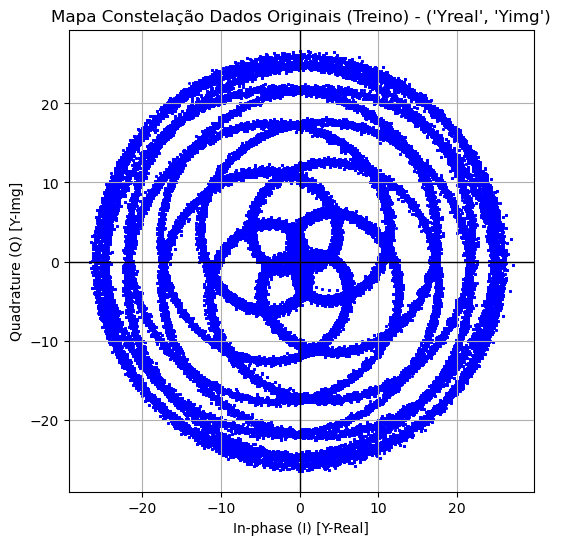

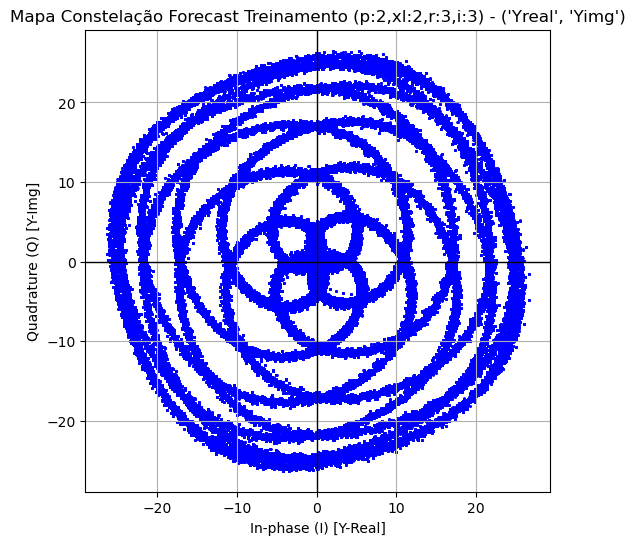

In [23]:
# Mapas de Constelação dos dados de Treino Reias e Forecast
drawn_constellation_map(train,title="Mapa Constelação Dados Originais (Treino)")
drawn_constellation_map(fc_train,title=f"Mapa Constelação Forecast Treinamento (p:{params['p']},xl:{params['x_lag']},r:{params['r']},i:{params['i']})")

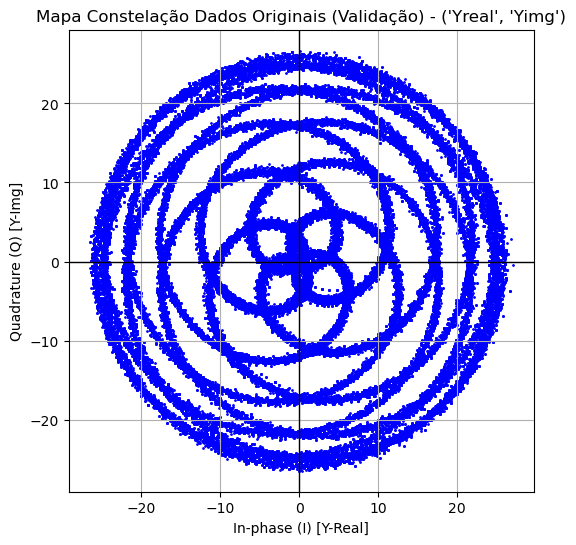

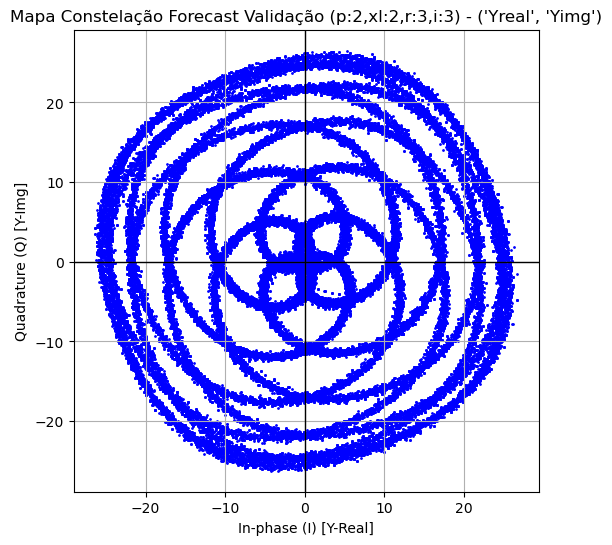

In [24]:
# Mapas de Constelação dos dados de Validação Reais e Forecast
drawn_constellation_map(val,title="Mapa Constelação Dados Originais (Validação)")
drawn_constellation_map(fc_val,title=f"Mapa Constelação Forecast Validação (p:{params['p']},xl:{params['x_lag']},r:{params['r']},i:{params['i']})")

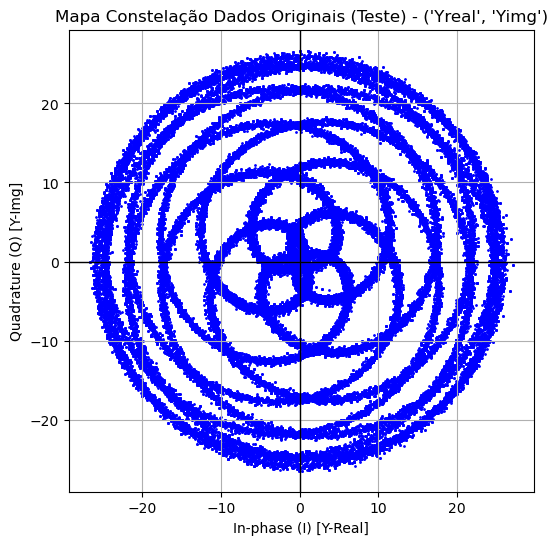

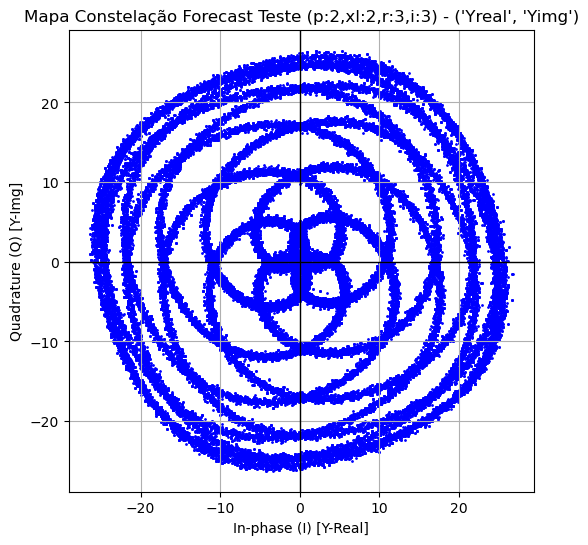

In [25]:
# Mapas de Constelação dos dados de Teste Reais e Forecast
drawn_constellation_map(test,title="Mapa Constelação Dados Originais (Teste)")
drawn_constellation_map(fc_test,title=f"Mapa Constelação Forecast Teste (p:{params['p']},xl:{params['x_lag']},r:{params['r']},i:{params['i']})")

#### Realizando Forecast Total dos Dados e Gerando Mapa de Magnetude

In [26]:
# ----------------------------
# Geração do Mapa de Magnetude
# ----------------------------
def drawn_magnitude_map(df_input,forecast,endog_cols:tuple=('Yreal','Yimg'),exog_cols:tuple=('Xreal','Ximg'),title:str="Mapa de Magnitude",save:bool=False):
  df_mag = pd.DataFrame()
  df_mag["MAG_Input"] = np.sqrt(df_input[exog_cols[0]]**2 + df_input[exog_cols[1]]**2)
  df_mag["MAG_Output_forecast"] = np.sqrt(forecast[endog_cols[0]]**2 + forecast[endog_cols[1]]**2)

  df_mag["MAG_Input_Decibel"] = 20*np.log10(df_mag["MAG_Input"])
  df_mag["MAG_Output_Decibel_forecast"] = 20*np.log10(df_mag["MAG_Output_forecast"])

  plt.plot(df_mag["MAG_Input_Decibel"],df_mag["MAG_Output_Decibel_forecast"],marker='o')
  plt.xlabel("MAG Input [dB]")
  plt.ylabel("MAG Output Forecast [dB]")
  plt.title(f"{title}")
  plt.grid(True)
  img_label = title.replace(" ","-").lower()
  
  if (save):
    plt.savefig(f"{img_label}.png")

  plt.show()

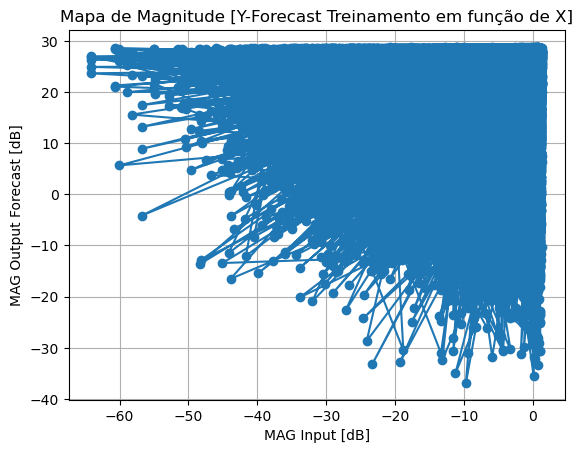

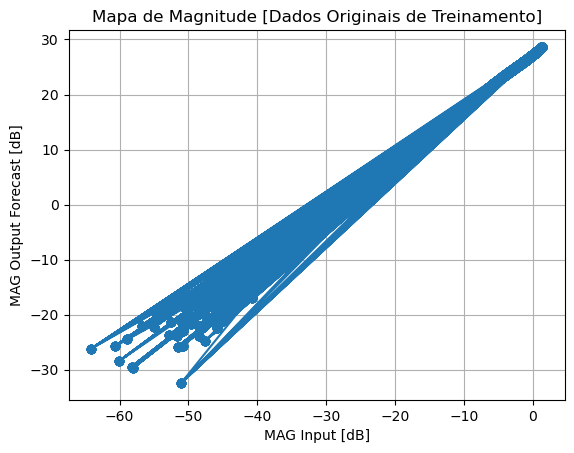

In [27]:
# Gerando Mapa de Magnitude para Dados de Treino (Originais e Forecast)
drawn_magnitude_map(df_train_test,fc_train,title="Mapa de Magnitude [Y-Forecast Treinamento em função de X]")
drawn_magnitude_map(df_train_test,df_train_test,title="Mapa de Magnitude [Dados Originais de Treinamento]")

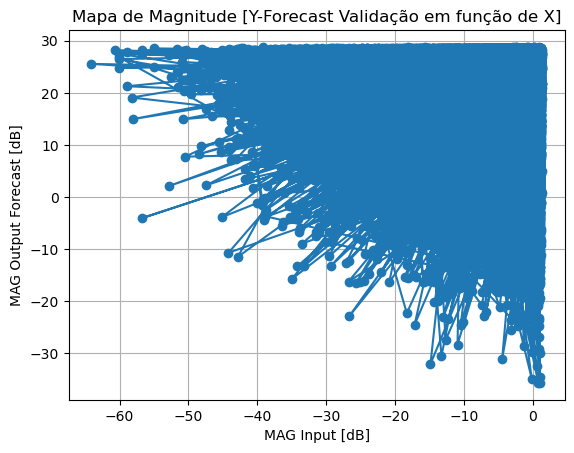

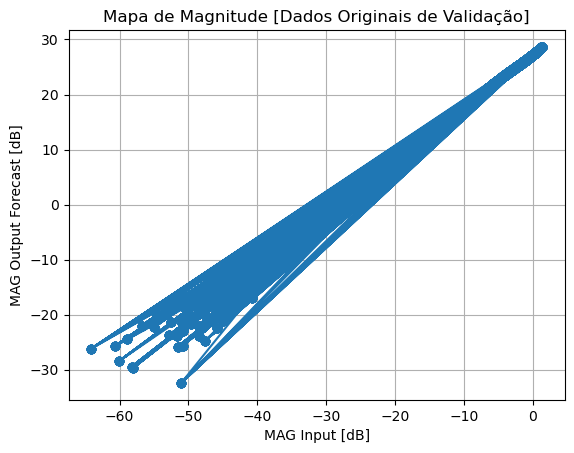

In [28]:
# Gerando Mapa de Magnitude para Dados de Validação (Originais e Forecast)
drawn_magnitude_map(df_train_test,fc_val,title="Mapa de Magnitude [Y-Forecast Validação em função de X]")
drawn_magnitude_map(df_train_test,df_train_test,title="Mapa de Magnitude [Dados Originais de Validação]")

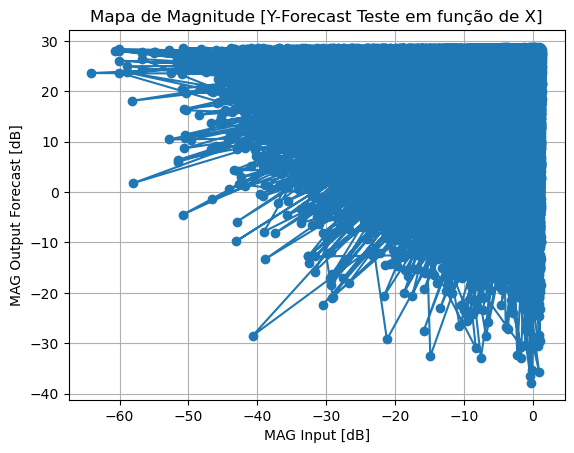

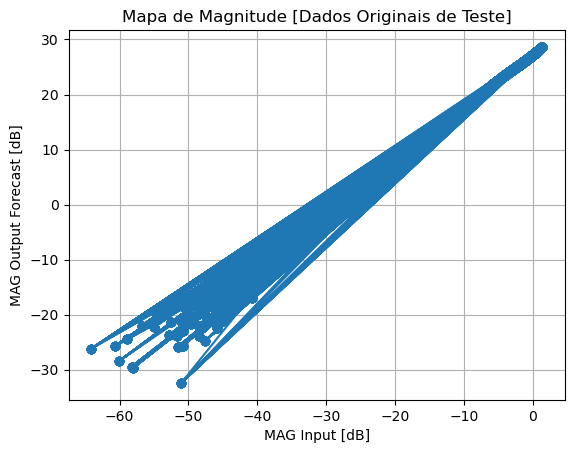

In [29]:
# Gerando Mapa de Magnitude para Dados de Teste (Originais e Forecast)
drawn_magnitude_map(df_train_test,fc_test,title="Mapa de Magnitude [Y-Forecast Teste em função de X]")
drawn_magnitude_map(df_train_test,df_train_test,title="Mapa de Magnitude [Dados Originais de Teste]")

#### Gerando forecast total dos dados

In [30]:
# Realizando o forecast de todos os dados
endog_total = df_train_test[list(["Yreal","Yimg"])]
exog_total = df_train_test[list(current_exog_cols)]

fc_total = final_res.forecast(steps=len(endog_total),exog=exog_total)
fc_total.index = endog_total.index

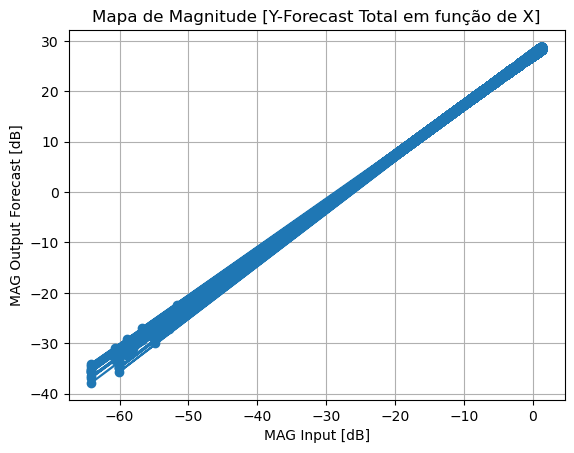

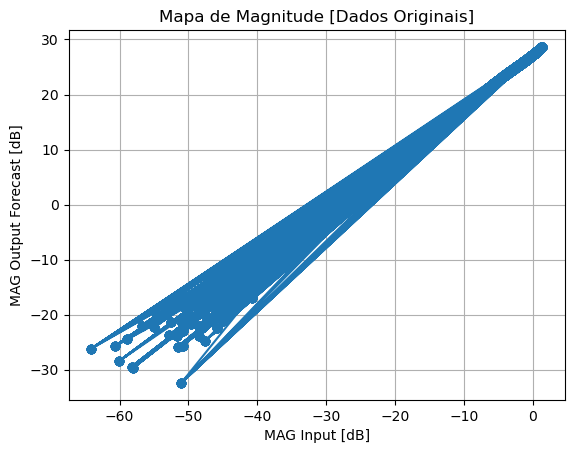

In [31]:
# Gerando Mapa de Magnitude
drawn_magnitude_map(df_train_test,fc_total,title="Mapa de Magnitude [Y-Forecast Total em função de X]")
drawn_magnitude_map(df_train_test,df_train_test,title="Mapa de Magnitude [Dados Originais]")